BOND

In [32]:
import os
import glob
import numpy as np
import pandas as pd
from pymatgen.core import Structure
from pymatgen.analysis.local_env import CrystalNN
from scipy.optimize import linear_sum_assignment

def find_motifs(contcar_file, magnetic_species, num_neighbors):
    """
    CONTCAR 파일에서 두 개의 자성원자 중심 motif를 추출합니다.
    
    각 motif는 다음을 포함합니다:
      - center_coord: 중심 자성원의 좌표
      - motif_coords: 중심 원자를 기준으로 한, 선택된 비자성원자들의 상대 좌표 (centered coordinates)
      - selected_neighbor_indices: 선택된 비자성원자의 원래 인덱스
      - distances: 중심과 각 이웃 사이의 거리
      
    Parameters:
      contcar_file (str): CONTCAR 파일 경로
      magnetic_species (list): 자성원소 심볼 리스트
      num_neighbors (int): 각 자성원자 주변에서 선택할 비자성원자의 최대 개수
      
    Returns:
      motifs (dict): 두 자성원자 인덱스를 key로 하여 각 motif 정보를 담은 딕셔너리
    """
    structure = Structure.from_file(contcar_file)
    
    # 자성원자에 해당하는 site 인덱스 찾기
    magnetic_indices = [i for i, site in enumerate(structure) if str(site.specie) in magnetic_species]
    if len(magnetic_indices) < 2:
        raise ValueError("CONTCAR에 자성원자가 2개 미만입니다.")
    
    # 자성원자가 2개보다 많으면 처음 두 개만 사용
    magnetic_indices = magnetic_indices[:2]
    
    cnn = CrystalNN()
    motifs = {}
    
    for mag_index in magnetic_indices:
        center_site = structure[mag_index]
        nn_info = cnn.get_nn_info(structure, mag_index)

        # 비자성원자만 선택 (자성원소 리스트에 포함되지 않는 원소)
        nonmag_neighbors = []
        nonmag_neighbor_indices = []
        for info in nn_info:
            neighbor_index = info.get("site_index", None)
            neighbor_site = info["site"]
            if str(neighbor_site.specie) not in magnetic_species:
                nonmag_neighbors.append(neighbor_site.coords)
                nonmag_neighbor_indices.append(neighbor_index)
        
        nonmag_neighbors = np.array(nonmag_neighbors)
        
        if nonmag_neighbors.shape[0] == 0:
            raise ValueError(f"자성원자 index {mag_index} 주변에 비자성원이 없습니다.")
        
        # 중심과의 거리를 계산하여 가장 가까운 이웃들을 선택합니다.
        distances = np.linalg.norm(nonmag_neighbors - center_site.coords, axis=1)
        actual_neighbors = min(num_neighbors, nonmag_neighbors.shape[0])
        sorted_idx = np.argsort(distances)[:actual_neighbors]
        selected_neighbors = nonmag_neighbors[sorted_idx]
        selected_indices = [nonmag_neighbor_indices[i] for i in sorted_idx]
        selected_distances = distances[sorted_idx]
        
        # 중심 좌표를 빼서 중심화된 상대 좌표를 계산
        motif_coords = selected_neighbors - center_site.coords
        
        motifs[mag_index] = {
            "center_coord": center_site.coords,
            "motif_coords": motif_coords,
            "selected_neighbor_indices": selected_indices,
            "distances": selected_distances
        }
    
    return motifs

def sort_motif_by_neighbor_indices(motif):
    """
    motif 딕셔너리 내에서 'selected_neighbor_indices'를 기준으로 오름차순 정렬하고,
    그에 맞게 'motif_coords'와 'distances'도 재정렬합니다.
    """
    sel_idx = np.array(motif["selected_neighbor_indices"])
    order = np.argsort(sel_idx)
    
    motif["selected_neighbor_indices"] = sel_idx[order].tolist()
    motif["motif_coords"] = motif["motif_coords"][order]
    motif["distances"] = motif["distances"][order]
    return motif

def compute_bond_length_stats(motif):
    """
    motif 내의 bond length (자성원자와 비자성원자 사이의 거리)에 대해 
    평균, 최대, 최소, 표준편차를 계산하여 딕셔너리로 반환합니다.
    """
    distances = motif["distances"]
    stats = {
        "avg_bond_length": np.mean(distances),
        "max_bond_length": np.max(distances),
        "min_bond_length": np.min(distances),
        "std_bond_length": np.std(distances)
    }
    return stats

def compute_magnetic_center_angles(motif):
    """
    비자성-자성-비자성 각도: 중심(자성원자, 원점)에서 두 비자성원자 벡터 사이의 각도를 구합니다.
    
    motif["motif_coords"]에 있는 모든 두 점에 대해, 각도를 계산합니다.
    (각도는 도(degree) 단위로 계산)
    
    Returns:
      stats (dict): 최대, 최소, 평균, 표준편차 각도.
    """
    points = motif["motif_coords"]
    n = points.shape[0]
    angles = []
    if n < 2:
        return {"max_angle": None, "min_angle": None, "avg_angle": None, "std_angle": None}
    
    for i in range(n):
        for j in range(i+1, n):
            v1 = points[i]
            v2 = points[j]
            norm1 = np.linalg.norm(v1)
            norm2 = np.linalg.norm(v2)
            if norm1 == 0 or norm2 == 0:
                continue
            cosine_angle = np.dot(v1, v2) / (norm1 * norm2)
            cosine_angle = np.clip(cosine_angle, -1.0, 1.0)
            angle = np.arccos(cosine_angle) * (180.0 / np.pi)
            angles.append(angle)
    angles = np.array(angles)
    if angles.size == 0:
        return {"max_angle": None, "min_angle": None, "avg_angle": None, "std_angle": None}
    stats = {
        "max_angle": np.max(angles),
        "min_angle": np.min(angles),
        "avg_angle": np.mean(angles),
        "std_angle": np.std(angles)
    }
    return stats

def compute_nonmagnetic_vertex_angles(motif):
    """
    비자성-비자성-비자성 각도: motif 내의 비자성원자 중 한 원자를 vertex로 하여,
    그 원자를 중심으로 하는 두 다른 비자성원자와의 각도를 구합니다.
    
    즉, motif 내의 세 점 A, B, C 중에서 B를 꼭짓점으로 angle(ABC)를 구합니다.
    
    Returns:
      stats (dict): 최대, 최소, 평균, 표준편차 각도 (도 단위).
    """
    points = motif["motif_coords"]
    n = points.shape[0]
    angles = []
    if n < 3:
        return {"max_angle": None, "min_angle": None, "avg_angle": None, "std_angle": None}
    
    for vertex in range(n):
        others = [i for i in range(n) if i != vertex]
        for i in range(len(others)):
            for j in range(i+1, len(others)):
                p1 = points[others[i]]
                p2 = points[others[j]]
                vertex_point = points[vertex]
                v1 = p1 - vertex_point
                v2 = p2 - vertex_point
                norm1 = np.linalg.norm(v1)
                norm2 = np.linalg.norm(v2)
                if norm1 == 0 or norm2 == 0:
                    continue
                cosine_angle = np.dot(v1, v2) / (norm1 * norm2)
                cosine_angle = np.clip(cosine_angle, -1.0, 1.0)
                angle = np.arccos(cosine_angle) * (180.0 / np.pi)
                angles.append(angle)
    angles = np.array(angles)
    if angles.size == 0:
        return {"max_angle": None, "min_angle": None, "avg_angle": None, "std_angle": None}
    stats = {
        "max_angle": np.max(angles),
        "min_angle": np.min(angles),
        "avg_angle": np.mean(angles),
        "std_angle": np.std(angles)
    }
    return stats

# DataFrame 생성: 각 파일별로 계산된 딕셔너리를 모아서 DataFrame으로 만듭니다.
data_list = []
# POSCAR 파일 대신 CONTCAR 파일 패턴 사용 (환경에 맞게 수정)
contcar_files = glob.glob(os.path.join("", "POSCAR_*"))
file_list = [f.replace(os.sep, "/") for f in contcar_files]
magnetic_species = ["Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn", 
                          "Y", "Zr", "Nb", "Mo", "Ru", "Rh", "Pd", "Ag", "Cd"]
for contcar_file in file_list:
    try:
        motifs = find_motifs(contcar_file, magnetic_species=magnetic_species, num_neighbors=12)
    except Exception:
        continue  # 에러 발생 시 건너뜁니다.
    
    keys = list(motifs.keys())
    if len(keys) < 2:
        continue  # 자성원자가 2개 미만이면 건너뜁니다.
    
    motif0 = sort_motif_by_neighbor_indices(motifs[keys[0]])
    motif1 = sort_motif_by_neighbor_indices(motifs[keys[1]])
    
    bond_stats0 = compute_bond_length_stats(motif0)
    bond_stats1 = compute_bond_length_stats(motif1)
    combined_bond_stats = {
        "avg_bond_length": (bond_stats0["avg_bond_length"] + bond_stats1["avg_bond_length"]) / 2,
        "max_bond_length": (bond_stats0["max_bond_length"] + bond_stats1["max_bond_length"]) / 2,
        "min_bond_length": (bond_stats0["min_bond_length"] + bond_stats1["min_bond_length"]) / 2,
        "std_bond_length": (bond_stats0["std_bond_length"] + bond_stats1["std_bond_length"]) / 2,
    }
    
    center_angles0 = compute_magnetic_center_angles(motif0)
    center_angles1 = compute_magnetic_center_angles(motif1)
    combined_center_angles = {
        "center_max_angle": (center_angles0["max_angle"] + center_angles1["max_angle"]) / 2 if center_angles0["max_angle"] is not None and center_angles1["max_angle"] is not None else None,
        "center_min_angle": (center_angles0["min_angle"] + center_angles1["min_angle"]) / 2 if center_angles0["min_angle"] is not None and center_angles1["min_angle"] is not None else None,
        "center_avg_angle": (center_angles0["avg_angle"] + center_angles1["avg_angle"]) / 2 if center_angles0["avg_angle"] is not None and center_angles1["avg_angle"] is not None else None,
        "center_std_angle": (center_angles0["std_angle"] + center_angles1["std_angle"]) / 2 if center_angles0["std_angle"] is not None and center_angles1["std_angle"] is not None else None,
    }
    
    nonmag_angles0 = compute_nonmagnetic_vertex_angles(motif0)
    nonmag_angles1 = compute_nonmagnetic_vertex_angles(motif1)
    combined_nonmag_angles = {
        "nonmag_max_angle": (nonmag_angles0["max_angle"] + nonmag_angles1["max_angle"]) / 2 if nonmag_angles0["max_angle"] is not None and nonmag_angles1["max_angle"] is not None else None,
        "nonmag_min_angle": (nonmag_angles0["min_angle"] + nonmag_angles1["min_angle"]) / 2 if nonmag_angles0["min_angle"] is not None and nonmag_angles1["min_angle"] is not None else None,
        #"nonmag_avg_angle": (nonmag_angles0["avg_angle"] + nonmag_angles1["avg_angle"]) / 2 if nonmag_angles0["avg_angle"] is not None and nonmag_angles1["avg_angle"] is not None else None,
        "nonmag_std_angle": (nonmag_angles0["std_angle"] + nonmag_angles1["std_angle"]) / 2 if nonmag_angles0["std_angle"] is not None and nonmag_angles1["std_angle"] is not None else None,
    }
    
    file_data = {"filename": contcar_file}
    file_data.update(combined_bond_stats)
    file_data.update(combined_center_angles)
    file_data.update(combined_nonmag_angles)
    data_list.append(file_data)

# DataFrame 생성 (출력하지 않고 변수 df에 저장)
BOND_df = pd.DataFrame(data_list)
BOND_df

,filename,avg_bond_length,max_bond_length,min_bond_length,std_bond_length,center_max_angle,center_min_angle,center_avg_angle,center_std_angle,nonmag_max_angle,nonmag_min_angle,nonmag_std_angle
0,POSCAR_Ag2F6_3,2.059812,2.071303,2.048707,0.009190,179.934945,89.265038,107.983854,35.970486,90.629465,44.471413,16.436340
1,POSCAR_Ag2F6_3_st025,2.111308,2.123085,2.099925,0.009420,179.934945,89.265038,107.983854,35.970486,90.629465,44.471413,16.436340
2,POSCAR_Ag2F6_3_st050,2.162803,2.174868,2.151143,0.009649,179.934945,89.265038,107.983854,35.970486,90.629465,44.471413,16.436340
3,POSCAR_Ag2F6_3_st950,1.956822,1.967738,1.946272,0.008730,179.934945,89.265038,107.983854,35.970486,90.629465,44.471413,16.436340
4,POSCAR_Ag2F6_3_st975,2.008317,2.019520,1.997490,0.008960,179.934945,89.265038,107.983854,35.970486,90.629465,44.471413,16.436340
...,...,...,...,...,...,...,...,...,...,...,...,...
5940,POSCAR_Tl2Zr2_1_z025,3.165312,3.166772,3.162922,0.001285,179.936171,67.511479,107.985136,41.096764,90.029752,33.760679,19.595762
5941,POSCAR_Tl2Zr2_1_z050,3.210736,3.212167,3.208372,0.001269,179.936543,66.432206,107.985286,41.575265,90.029147,33.220718,19.854611
5942,POSCAR_Tl2Zr2_1_z950,3.031863,3.033416,3.029391,0.001338,179.935198,70.913817,107.984688,39.705912,90.031715,35.462955,18.820800
5943,POSCAR_Tl2Zr2_1_z975,3.075855,3.077376,3.073411,0.001320,179.935496,69.751791,107.984836,40.160164,90.031035,34.881549,19.077975


In [9]:
rows_with_nan = BOND_df[BOND_df.isna().any(axis=1)]
rows_with_nan

,filename,avg_bond_length,max_bond_length,min_bond_length,std_bond_length,center_max_angle,center_min_angle,center_avg_angle,center_std_angle,nonmag_max_angle,nonmag_min_angle,nonmag_std_angle
1208,POSCAR_C2Pd2_1,2.054824,2.054824,2.054824,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1209,POSCAR_C2Ru2_5,2.085220,2.117359,2.053081,0.032139,124.609509,124.609509,124.609509,0.0,NaN,NaN,NaN
1227,POSCAR_C4Mn2_1,2.640891,2.643378,2.638405,0.002487,179.241202,179.241202,179.241202,0.0,NaN,NaN,NaN
1228,POSCAR_C4Mn2_1_st025,2.706913,2.709462,2.704365,0.002549,179.241202,179.241202,179.241202,0.0,NaN,NaN,NaN
1229,POSCAR_C4Mn2_1_st050,2.772936,2.775547,2.770325,0.002611,179.241202,179.241202,179.241202,0.0,NaN,NaN,NaN
1230,POSCAR_C4Mn2_1_st950,2.508847,2.511209,2.506484,0.002362,179.241202,179.241202,179.241202,0.0,NaN,NaN,NaN
1231,POSCAR_C4Mn2_1_st975,2.574869,2.577293,2.572444,0.002424,179.241202,179.241202,179.241202,0.0,NaN,NaN,NaN
3165,POSCAR_Fe2N2_3,1.909323,1.909323,1.909323,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3166,POSCAR_Fe2N2_3_st025,1.957056,1.957056,1.957056,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3167,POSCAR_Fe2N2_3_st050,2.004789,2.004789,2.004789,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
import os
import glob
import numpy as np
import pandas as pd
from pymatgen.core import Structure

def distinct_values(sorted_values, threshold=0.01):
    """
    정렬된 값 리스트에서, 연속된 값의 차이가 threshold 이하이면 동일한 값으로 간주하고,
    고유한 값들만 추출합니다.
    """
    distinct = []
    for d in sorted_values:
        if not distinct or (d - distinct[-1]) > threshold:
            distinct.append(d)
    return distinct

def compute_labelled_min_magnetic_distances(structure, magnetic_species, num_neighbors=3, translation_range=(-1, 0, 1), threshold=0.1):
    """
    구조에 자성원자가 정확히 2개 있다고 가정하고, 
    Ag1→Ag2 (forward)와 Ag2→Ag1 (reverse) 방향으로 계산한 periodic image 거리 목록을 구합니다.
    각 순위별로 두 방향에서 얻은 고유 거리 값 중 최솟값을 사용합니다.
    
    Returns:
      features (dict): "labelled_1st", "labelled_2nd", "labelled_3rd" 값을 포함하는 딕셔너리.
    """
    # 자성원자 인덱스 (정확히 2개)
    magnetic_indices = [i for i, site in enumerate(structure) if str(site.specie) in magnetic_species]
    if len(magnetic_indices) != 2:
        raise ValueError("구조에는 정확히 2개의 자성원자가 있어야 합니다.")
    
    idx1, idx2 = magnetic_indices
    lattice = structure.lattice
    coords1 = structure[idx1].coords
    coords2 = structure[idx2].coords
    
    forward = []
    reverse = []
    for i in translation_range:
        for j in translation_range:
            for k in translation_range:
                t = i * lattice.matrix[0] + j * lattice.matrix[1] + k * lattice.matrix[2]
                d_f = np.linalg.norm(coords2 + t - coords1)
                d_r = np.linalg.norm(coords1 + t - coords2)
                forward.append(d_f)
                reverse.append(d_r)
    forward = np.sort(np.array(forward))
    reverse = np.sort(np.array(reverse))
    
    distinct_forward = distinct_values(forward, threshold)
    distinct_reverse = distinct_values(reverse, threshold)
    
    labelled = []
    for i in range(num_neighbors):
        d1 = distinct_forward[i] if i < len(distinct_forward) else np.nan
        d2 = distinct_reverse[i] if i < len(distinct_reverse) else np.nan
        # 두 값 중 nan이 아니면 최솟값 선택
        if np.isnan(d1) and np.isnan(d2):
            labelled.append(np.nan)
        elif np.isnan(d1):
            labelled.append(d2)
        elif np.isnan(d2):
            labelled.append(d1)
        else:
            labelled.append(min(d1, d2))
    
    features = {
        "labelled_1st": labelled[0],
        "labelled_2nd": labelled[1],
        "labelled_3rd": labelled[2]
    }
    return features

def compute_global_min_magnetic_distances(structure, magnetic_species, num_neighbors=3, translation_range=(-1, 0, 1), threshold=0.1):
    """
    구조에 자성원자가 정확히 2개 있을 때,  
    (1) Ag1과 Ag2 사이의 모든 cross periodic image 거리와  
    (2) 각 원자(Ag1, Ag2)의 자기 자신의 non-trivial periodic image (trivial (0,0,0)은 제외) 거리를
    모두 계산하여 합칩니다.
    이 전체 값들에서 고유한 값을 추출한 후, 각 순위별 최솟값을 사용합니다.
    
    Returns:
      features (dict): "global_1st", "global_2nd", "global_3rd" 값을 포함하는 딕셔너리.
    """
    magnetic_indices = [i for i, site in enumerate(structure) if str(site.specie) in magnetic_species]
    if len(magnetic_indices) != 2:
        raise ValueError("구조에는 정확히 2개의 자성원자가 있어야 합니다.")
    
    lattice = structure.lattice
    coords = [structure[i].coords for i in magnetic_indices]
    
    all_distances = []
    # Cross distances: Ag1->Ag2 (두 방향)
    for i in range(2):
        for j in range(2):
            if i != j:
                for a in translation_range:
                    for b in translation_range:
                        for c in translation_range:
                            t = a * lattice.matrix[0] + b * lattice.matrix[1] + c * lattice.matrix[2]
                            d = np.linalg.norm(coords[j] + t - coords[i])
                            all_distances.append(d)
    # Self distances: 각 원자에 대해 (0,0,0)은 제외
    for i in range(2):
        for a in translation_range:
            for b in translation_range:
                for c in translation_range:
                    if a == 0 and b == 0 and c == 0:
                        continue
                    t = a * lattice.matrix[0] + b * lattice.matrix[1] + c * lattice.matrix[2]
                    d = np.linalg.norm(coords[i] + t - coords[i])
                    all_distances.append(d)
    all_distances = np.array(all_distances)
    all_distances = np.sort(all_distances)
    distinct_all = distinct_values(all_distances, threshold)
    
    features = {}
    features["global_1st"] = distinct_all[0] if len(distinct_all) >= 1 else np.nan
    features["global_2nd"] = distinct_all[1] if len(distinct_all) >= 2 else np.nan
    features["global_3rd"] = distinct_all[2] if len(distinct_all) >= 3 else np.nan
    
    return features

# Data 수집 및 DataFrame 생성
data_list = []
# 여기서는 CONTCAR 파일들을 대상으로 합니다.
contcar_files = glob.glob(os.path.join("", "POSCAR_*"))
file_list = [f.replace(os.sep, "/") for f in contcar_files]

# 사용할 자성원소 (예시)
magnetic_species = ["Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn", 
                    "Y", "Zr", "Nb", "Mo", "Ru", "Rh", "Pd", "Ag", "Cd"]

for contcar_file in file_list:
    try:
        structure = Structure.from_file(contcar_file)
    except Exception:
        continue
    try:
        labelled_features = compute_labelled_min_magnetic_distances(
            structure, magnetic_species, num_neighbors=3, translation_range=(-1, 0, 1), threshold=0.1)
        global_features = compute_global_min_magnetic_distances(
            structure, magnetic_species, num_neighbors=3, translation_range=(-1, 0, 1), threshold=0.1)
    except Exception:
        continue
    
    file_data = {"filename": contcar_file}
    file_data.update(labelled_features)
    file_data.update(global_features)
    data_list.append(file_data)

# DataFrame 생성 (df 변수에 저장)
NN_df = pd.DataFrame(data_list)
NN_df

,filename,labelled_1st,labelled_2nd,labelled_3rd,global_1st,global_2nd,global_3rd
0,POSCAR_Ag2F6_3,3.984771,6.845202,7.072061,3.984771,5.616773,5.845995
1,POSCAR_Ag2F6_3_st025,4.084390,7.016332,7.248210,4.084390,5.757192,5.992145
2,POSCAR_Ag2F6_3_st050,4.184009,7.187462,7.424996,4.184009,5.897612,6.138294
3,POSCAR_Ag2F6_3_st950,3.785532,6.502942,6.717853,3.785532,5.335934,5.553695
4,POSCAR_Ag2F6_3_st975,3.885151,6.674072,6.894639,3.885151,5.476354,5.699845
...,...,...,...,...,...,...,...
5940,POSCAR_Tl2Zr2_1_z025,4.843475,5.985653,7.793224,3.518708,4.843475,5.985653
5941,POSCAR_Tl2Zr2_1_z050,4.961609,6.081644,7.867189,3.518708,4.961609,6.081644
5942,POSCAR_Tl2Zr2_1_z950,4.489075,5.702672,7.578050,3.518708,4.489075,5.702672
5943,POSCAR_Tl2Zr2_1_z975,4.607208,5.796126,7.648623,3.518708,4.607208,5.796126


In [11]:
rows_with_nan = NN_df[NN_df.isna().any(axis=1)]
rows_with_nan

,filename,labelled_1st,labelled_2nd,labelled_3rd,global_1st,global_2nd,global_3rd


In [4]:
import os
import glob
import numpy as np
import pandas as pd
from pymatgen.core import Structure
from pymatgen.analysis.local_env import CrystalNN
from scipy.spatial import ConvexHull, QhullError

def find_motifs(contcar_file, magnetic_species, num_neighbors):
    structure = Structure.from_file(contcar_file)
    magnetic_indices = [i for i, site in enumerate(structure) if str(site.specie) in magnetic_species]
    if len(magnetic_indices) < 2:
        raise ValueError("CONTCAR에 자성원자가 2개 미만입니다.")
    magnetic_indices = magnetic_indices[:2]

    cnn = CrystalNN()
    motifs = {}
    for mag_index in magnetic_indices:
        center_site = structure[mag_index]
        nn_info = cnn.get_nn_info(structure, mag_index)
        nonmag_neighbors = []
        for info in nn_info:
            neighbor_site = info["site"]
            if str(neighbor_site.specie) not in magnetic_species:
                nonmag_neighbors.append(neighbor_site.coords)
        nonmag_neighbors = np.array(nonmag_neighbors)
        if nonmag_neighbors.shape[0] == 0:
            raise ValueError(f"자성원자 index {mag_index} 주변에 비자성원이 없습니다.")
        distances = np.linalg.norm(nonmag_neighbors - center_site.coords, axis=1)
        actual_neighbors = min(num_neighbors, nonmag_neighbors.shape[0])
        sorted_idx = np.argsort(distances)[:actual_neighbors]
        selected_neighbors = nonmag_neighbors[sorted_idx]
        motif_coords = selected_neighbors - center_site.coords
        motifs[mag_index] = {"center_coord": center_site.coords, "motif_coords": motif_coords}
    return motifs

def compute_motif_properties_2d(points, tolerance=1e-6):
    """2D motif의 convex hull 면적 및 평면 normal 계산"""
    if points.shape[0] < 3:
        return None, None, None
    
    center = np.mean(points, axis=0)
    centered = points - center
    
    try:
        U, S, Vt = np.linalg.svd(centered, full_matrices=False)
    except np.linalg.LinAlgError:
        return None, None, None
    
    if len(S) < 2 or S[1] < tolerance:
        return None, None, None
    
    projection_matrix = Vt[:2, :]
    projected = np.dot(centered, projection_matrix.T)
    
    # Plane normal vector
    plane_normal = Vt[2, :]
    plane_normal = plane_normal / np.linalg.norm(plane_normal)
    
    try:
        hull2d = ConvexHull(projected)
        area = hull2d.volume
    except (QhullError, ValueError):
        return None, None, None
    
    return area, area, plane_normal

def compute_motif_properties_3d(points):
    """3D motif의 convex hull 부피 계산"""
    if points.shape[0] < 4:
        return None, None
    
    try:
        hull = ConvexHull(points)
        return hull.volume, hull.area
    except (QhullError, ValueError):
        return None, None

def compute_motif_convex_properties(motif, tolerance=1e-6):
    """Motif의 차원을 판별하고 적절한 convex hull 계산"""
    points = motif["motif_coords"]
    if points.shape[0] < 3:
        return {"hull_volume": None, "hull_area": None, "dimension": None, "plane_normal": None}
    
    centered = points - np.mean(points, axis=0)
    
    try:
        U, S, Vt = np.linalg.svd(centered, full_matrices=False)
        rank = np.sum(S > tolerance * S[0]) if S[0] > 0 else 0
    except np.linalg.LinAlgError:
        return {"hull_volume": None, "hull_area": None, "dimension": None, "plane_normal": None}
    
    if rank == 2:
        hull_area, _, plane_normal = compute_motif_properties_2d(points, tolerance)
        return {
            "hull_volume": None,
            "hull_area": hull_area,
            "dimension": 2,
            "plane_normal": plane_normal
        }
    elif rank >= 3:
        hull_vol, hull_area = compute_motif_properties_3d(points)
        return {
            "hull_volume": hull_vol,
            "hull_area": hull_area,
            "dimension": 3,
            "plane_normal": None
        }
    else:
        return {"hull_volume": None, "hull_area": None, "dimension": rank, "plane_normal": None}

def find_most_parallel_face(structure, motif_plane_normal):
    """Motif plane과 가장 평행한 unit cell 면 찾기"""
    lattice = structure.lattice
    a = lattice.matrix[0]
    b = lattice.matrix[1]
    c = lattice.matrix[2]
    
    # 각 면의 normal vector
    normal_ab = np.cross(a, b)
    normal_bc = np.cross(b, c)
    normal_ca = np.cross(c, a)
    
    # 정규화
    normal_ab = normal_ab / np.linalg.norm(normal_ab)
    normal_bc = normal_bc / np.linalg.norm(normal_bc)
    normal_ca = normal_ca / np.linalg.norm(normal_ca)
    
    # 각도 계산
    cos_angle_ab = abs(np.dot(motif_plane_normal, normal_ab))
    cos_angle_bc = abs(np.dot(motif_plane_normal, normal_bc))
    cos_angle_ca = abs(np.dot(motif_plane_normal, normal_ca))
    
    angle_ab = np.arccos(np.clip(cos_angle_ab, 0, 1)) * 180 / np.pi
    angle_bc = np.arccos(np.clip(cos_angle_bc, 0, 1)) * 180 / np.pi
    angle_ca = np.arccos(np.clip(cos_angle_ca, 0, 1)) * 180 / np.pi
    
    # 면적 계산
    area_ab = np.linalg.norm(np.cross(a, b))
    area_bc = np.linalg.norm(np.cross(b, c))
    area_ca = np.linalg.norm(np.cross(c, a))
    
    angles = [angle_ab, angle_bc, angle_ca]
    areas = [area_ab, area_bc, area_ca]
    face_types = ['ab', 'bc', 'ca']
    
    best_idx = np.argmin(angles)
    
    return {
        'best_face_area': areas[best_idx],
        'best_face_type': face_types[best_idx],
        'angle_degrees': angles[best_idx],
        'median_face_area': np.median(areas),
        'all_areas': areas,
        'all_angles': angles
    }

def compute_unit_cell_measure_2d_hybrid(structure, motif_plane_normal, safety_factor=0.5):
    """
    ⭐ HYBRID METHOD ⭐
    
    가장 평행한 면을 기본으로 하되, 안전장치 추가:
    - 평행한 면이 median의 safety_factor 이하면 median 사용
    - 이를 통해 >1 위험 최소화
    
    Parameters:
    -----------
    structure : Structure
    motif_plane_normal : ndarray
        Motif 평면의 normal vector
    safety_factor : float
        안전 임계값 (기본: 0.5)
        평행한 면 < safety_factor × median이면 median 사용
    
    Returns:
    --------
    dict with:
        'area': 사용된 면적
        'method': 'parallel_face' or 'median_safeguard'
        'parallel_area': 평행한 면의 면적
        'median_area': 중앙값
        'safety_triggered': 안전장치 발동 여부
    """
    face_info = find_most_parallel_face(structure, motif_plane_normal)
    parallel_area = face_info['best_face_area']
    median_area = face_info['median_face_area']
    
    # 안전장치 체크
    if parallel_area < safety_factor * median_area:
        # 평행한 면이 너무 작음 → median 사용
        selected_area = median_area
        method = "median_safeguard"
        safety_triggered = True
    else:
        # 평행한 면이 충분히 큼 → 평행한 면 사용
        selected_area = parallel_area
        method = "parallel_face"
        safety_triggered = False
    
    return {
        'area': selected_area,
        'method': method,
        'parallel_area': parallel_area,
        'median_area': median_area,
        'safety_triggered': safety_triggered,
        'best_face_type': face_info['best_face_type'],
        'angle_degrees': face_info['angle_degrees']
    }

def compute_comparable_metrics(raw_ratio, dimension):
    """2D와 3D를 비교 가능한 지표로 변환"""
    if raw_ratio is None or dimension is None:
        return {
            "characteristic_length_ratio": None,
            "packing_fraction": None,
        }
    
    if dimension == 2:
        characteristic_length_ratio = np.sqrt(raw_ratio)
    elif dimension == 3:
        characteristic_length_ratio = np.cbrt(raw_ratio)
    else:
        characteristic_length_ratio = raw_ratio
    
    return {
        "characteristic_length_ratio": characteristic_length_ratio,
        "packing_fraction": raw_ratio,
    }

# 결과를 저장할 리스트
data_list = []

# CONTCAR 파일 목록
contcar_files = glob.glob(os.path.join("", "POSCAR_*"))
file_list = [f.replace(os.sep, "/") for f in contcar_files]

# 설정
SAFETY_FACTOR = 0.5  # 조정 가능 (0.3~0.7 권장)

print(f"Found {len(file_list)} POSCAR files to process")
print("\n" + "="*80)
print("⭐ HYBRID METHOD ⭐")
print("  Strategy: Most parallel face by default")
print("  Safety: Use median if parallel face < 50% of median")
print(f"  Safety factor: {SAFETY_FACTOR}")
print("  Goal: Maximize accuracy while minimizing f>1 risk")
print("="*80 + "\n")

safety_triggered_count = 0

for idx, contcar_file in enumerate(file_list, 1):
    if idx % 10 == 0:
        print(f"Processing {idx}/{len(file_list)}...")
    
    try:
        motifs = find_motifs(contcar_file, 
                             magnetic_species=["Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn", 
                                               "Y", "Zr", "Nb", "Mo", "Ru", "Rh", "Pd", "Ag", "Cd"], 
                             num_neighbors=12)
    except Exception as e:
        continue
    
    keys = list(motifs.keys())
    if len(keys) < 2:
        continue
    
    motif0 = find_motifs.__wrapped__ if hasattr(find_motifs, '__wrapped__') else motifs[keys[0]]
    motif1 = motifs[keys[1]]
    
    motif0 = motifs[keys[0]]
    motif1 = motifs[keys[1]]
    
    # 각 motif의 convex 특성 계산
    convex0 = compute_motif_convex_properties(motif0)
    convex1 = compute_motif_convex_properties(motif1)
    
    # 두 motif의 차원이 다르면 skip
    if convex0["dimension"] != convex1["dimension"]:
        continue
    
    if convex0["dimension"] is None or convex0["dimension"] < 2:
        continue
    
    dimension = convex0["dimension"]
    
    # 구조 정보
    structure = Structure.from_file(contcar_file)
    unit_cell_volume = structure.lattice.volume
    
    # 차원에 따라 다른 계산
    if dimension == 2:
        # 2D motif: HYBRID METHOD
        if (convex0["hull_area"] is not None and convex1["hull_area"] is not None and
            convex0["plane_normal"] is not None and convex1["plane_normal"] is not None):
            
            avg_motif_measure = (convex0["hull_area"] + convex1["hull_area"]) / 2
            
            # 평균 plane normal
            avg_plane_normal = (convex0["plane_normal"] + convex1["plane_normal"]) / 2
            avg_plane_normal = avg_plane_normal / np.linalg.norm(avg_plane_normal)
            
            # ⭐ HYBRID METHOD 적용
            cell_info = compute_unit_cell_measure_2d_hybrid(
                structure, avg_plane_normal, safety_factor=SAFETY_FACTOR
            )
            
            unit_cell_measure = cell_info['area']
            method_used = cell_info['method']
            
            if cell_info['safety_triggered']:
                safety_triggered_count += 1
            
            if unit_cell_measure > 0:
                ratio = avg_motif_measure / unit_cell_measure
            else:
                ratio = None
            
            # 추가 정보
            best_face_type = cell_info['best_face_type']
            parallel_angle = cell_info['angle_degrees']
            parallel_area = cell_info['parallel_area']
            median_area = cell_info['median_area']
            safety_triggered = cell_info['safety_triggered']
            
        else:
            avg_motif_measure = None
            unit_cell_measure = None
            ratio = None
            method_used = None
            best_face_type = None
            parallel_angle = None
            parallel_area = None
            median_area = None
            safety_triggered = None
            
    elif dimension == 3:
        # 3D motif
        if convex0["hull_volume"] is not None and convex1["hull_volume"] is not None:
            avg_motif_measure = (convex0["hull_volume"] + convex1["hull_volume"]) / 2
            unit_cell_measure = unit_cell_volume
            
            if unit_cell_measure > 0:
                ratio = avg_motif_measure / unit_cell_measure
            else:
                ratio = None
        else:
            avg_motif_measure = None
            unit_cell_measure = unit_cell_volume
            ratio = None
        
        method_used = "volume_ratio"
        best_face_type = None
        parallel_angle = None
        parallel_area = None
        median_area = None
        safety_triggered = None
    else:
        continue
    
    # 여전히 >1이면 경고
    if ratio is not None and ratio > 1.0:
        print(f"⚠️  WARNING: {contcar_file}")
        print(f"  f = {ratio:.3f} > 1.0 even with hybrid method!")
        print(f"  Dimension: {dimension}D")
        print(f"  Motif measure: {avg_motif_measure:.3f}")
        print(f"  Cell measure: {unit_cell_measure:.3f}")
        if dimension == 2:
            print(f"  Method used: {method_used}")
            print(f"  Parallel area: {parallel_area:.3f}")
            print(f"  Median area: {median_area:.3f}")
        print(f"  → Setting to None")
        ratio = None
    
    # 비교 가능한 지표 계산
    comparable = compute_comparable_metrics(ratio, dimension)

    data_list.append({
        "filename": contcar_file,
        "dimension": dimension,
        "avg_motif_measure": avg_motif_measure,
        "unit_cell_volume": unit_cell_volume,
        "unit_cell_measure_used": unit_cell_measure,
        "method_used": method_used,
        "best_face_type": best_face_type,
        "parallel_angle": parallel_angle,
        "parallel_area": parallel_area,
        "median_area": median_area,
        "safety_triggered": safety_triggered,
        "packing_fraction": comparable["packing_fraction"],
        "characteristic_length_ratio": comparable["characteristic_length_ratio"],
    })

print(f"\nProcessing complete. Successfully analyzed {len(data_list)} structures.")
print(f"Safety triggered: {safety_triggered_count} times")

# DataFrame 생성
VOL_df = pd.DataFrame(data_list)

# 기본 통계 출력
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

for dim in [2, 3]:
    subset = VOL_df[VOL_df['dimension'] == dim]
    if len(subset) > 0:
        print(f"\n{dim}D Structures (n={len(subset)}):")
        if dim == 2:
            print(f"  Method: HYBRID (parallel + median safeguard)")
            
            # Method 분포
            method_counts = subset['method_used'].value_counts()
            for method, count in method_counts.items():
                pct = count / len(subset) * 100
                print(f"    {method}: {count} ({pct:.1f}%)")
            
            if subset['parallel_angle'].notna().sum() > 0:
                print(f"  Avg alignment angle: {subset['parallel_angle'].mean():.1f}°")
        else:
            print(f"  Method: Volume / Volume")
        
        if subset['packing_fraction'].notna().sum() > 0:
            print(f"  Packing fraction:")
            print(f"    Mean: {subset['packing_fraction'].mean():.4f}")
            print(f"    Std:  {subset['packing_fraction'].std():.4f}")
            print(f"    Min:  {subset['packing_fraction'].min():.4f}")
            print(f"    Max:  {subset['packing_fraction'].max():.4f}")
            
            # >1 체크
            over_one = subset[subset['packing_fraction'] > 1.0]
            if len(over_one) > 0:
                print(f"    ⚠️  f>1: {len(over_one)} structures ({len(over_one)/len(subset)*100:.1f}%)")
        
        if subset['characteristic_length_ratio'].notna().sum() > 0:
            print(f"  Characteristic length ratio:")
            print(f"    Mean: {subset['characteristic_length_ratio'].mean():.4f}")
            print(f"    Std:  {subset['characteristic_length_ratio'].std():.4f}")

# CSV 저장
output_file = "motif_metrics_hybrid.csv"
VOL_df.to_csv(output_file, index=False)
print(f"\n✅ Results saved to: {output_file}")

print("\n" + "="*80)
print("⭐ HYBRID METHOD SUMMARY ⭐")
print(f"  Safety factor: {SAFETY_FACTOR}")
print(f"  Safety triggered: {safety_triggered_count}/{len(VOL_df[VOL_df['dimension']==2])} 2D structures")
print("  Advantage: Best balance of accuracy and stability")
print("="*80 + "\n")

VOL_df

Found 6 POSCAR files to process

⭐ HYBRID METHOD ⭐
  Strategy: Most parallel face by default
  Safety: Use median if parallel face < 50% of median
  Safety factor: 0.5
  Goal: Maximize accuracy while minimizing f>1 risk


Processing complete. Successfully analyzed 6 structures.
Safety triggered: 0 times

SUMMARY STATISTICS

2D Structures (n=3):
  Method: HYBRID (parallel + median safeguard)
    parallel_face: 3 (100.0%)
  Avg alignment angle: 50.0°
  Packing fraction:
    Mean: 0.5233
    Std:  0.0084
    Min:  0.5164
    Max:  0.5327
  Characteristic length ratio:
    Mean: 0.7234
    Std:  0.0058

3D Structures (n=3):
  Method: Volume / Volume
  Packing fraction:
    Mean: 0.3333
    Std:  0.0000
    Min:  0.3333
    Max:  0.3333
  Characteristic length ratio:
    Mean: 0.6934
    Std:  0.0000

✅ Results saved to: motif_metrics_hybrid.csv

⭐ HYBRID METHOD SUMMARY ⭐
  Safety factor: 0.5
  Safety triggered: 0/3 2D structures
  Advantage: Best balance of accuracy and stability



c:\Users\JKC\anaconda3\Lib\site-packages\pymatgen\analysis\local_env.py:4021: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r1 = _get_radius(structure[n])
c:\Users\JKC\anaconda3\Lib\site-packages\pymatgen\analysis\local_env.py:4023: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r2 = _get_radius(entry["site"])
c:\Users\JKC\anaconda3\Lib\site-packages\pymatgen\analysis\local_env.py:3935: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  nn_data = self.get_nn_data(structure, n)


,filename,dimension,avg_motif_measure,unit_cell_volume,unit_cell_measure_used,method_used,best_face_type,parallel_angle,parallel_area,median_area,safety_triggered,packing_fraction,characteristic_length_ratio
0,POSCAR_CoO,2,7.777583,40.109611,14.933378,parallel_face,ca,34.281986,14.933378,14.933378,False,0.520819,0.721678
1,POSCAR_CoS,3,20.942945,62.828835,62.828835,volume_ratio,None,NaN,NaN,NaN,None,0.333333,0.693361
2,POSCAR_CrS,2,14.703116,98.562648,28.471068,parallel_face,ca,59.001746,28.471068,28.469120,False,0.516423,0.718626
3,POSCAR_FeAs,3,23.565518,70.696554,70.696554,volume_ratio,None,NaN,NaN,NaN,None,0.333333,0.693361
4,POSCAR_FeS,2,10.917530,63.925074,20.494006,parallel_face,ca,56.692019,20.494006,20.494006,False,0.532718,0.729875
5,POSCAR_NiS,3,19.822369,59.467106,59.467106,volume_ratio,None,NaN,NaN,NaN,None,0.333333,0.693361


In [30]:
VOL_df[VOL_df['characteristic_length_ratio']>0.7]

,filename,dimension,avg_motif_measure,unit_cell_volume,unit_cell_measure_used,method_used,best_face_type,parallel_angle,parallel_area,median_area,safety_triggered,packing_fraction,characteristic_length_ratio
37,POSCAR_Al1Fe2_2,3,21.405784,42.811568,42.811568,volume_ratio,None,NaN,NaN,NaN,None,0.500000,0.793701
38,POSCAR_Al1Mn2_1,2,9.717242,50.583840,9.717242,parallel_face,ab,0.000000,9.717242,16.929417,False,1.000000,1.000000
39,POSCAR_Al2Co2_1,3,23.131814,46.259169,46.259169,volume_ratio,None,NaN,NaN,NaN,None,0.500048,0.793726
40,POSCAR_Al2Co2_2,3,20.203450,48.771173,48.771173,volume_ratio,None,NaN,NaN,NaN,None,0.414250,0.745454
41,POSCAR_Al2Cr2_1,3,33.166939,66.329127,66.329127,volume_ratio,None,NaN,NaN,NaN,None,0.500036,0.793719
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5846,POSCAR_Sn2Ti2_2,3,41.553072,83.106144,83.106144,volume_ratio,None,NaN,NaN,NaN,None,0.500000,0.793701
5847,POSCAR_Sn2Zr2_2,3,46.700708,93.398832,93.398832,volume_ratio,None,NaN,NaN,NaN,None,0.500014,0.793708
5849,POSCAR_Sn4V2_3,3,62.585342,140.725242,140.725242,volume_ratio,None,NaN,NaN,NaN,None,0.444734,0.763309
5905,POSCAR_Ti2Tl1_1,2,11.659821,58.778794,18.147662,parallel_face,ca,0.210475,18.147662,18.147662,False,0.642497,0.801559


In [22]:
VOL_df.describe()

,dimension,avg_motif_measure,unit_cell_volume,unit_cell_measure_used,parallel_angle,parallel_area,median_area,packing_fraction,characteristic_length_ratio
count,5924.000000,5924.000000,5924.000000,5924.000000,2.160000e+02,216.000000,216.000000,5916.000000,5916.000000
mean,2.963538,22.945650,119.411065,117.693075,2.417059e+01,16.679067,19.089057,0.230314,0.588350
std,0.187452,13.422056,75.353527,76.818469,2.106007e+01,6.643265,6.330492,0.127001,0.112711
min,2.000000,0.000215,23.878530,6.932737,0.000000e+00,6.205782,7.622182,0.000004,0.016177
25%,3.000000,11.762226,67.119173,65.269620,8.537736e-07,11.810656,15.017620,0.128143,0.500296
50%,3.000000,21.290521,96.932828,96.294718,3.328851e+01,15.438071,17.419810,0.193832,0.578512
75%,3.000000,31.270778,149.854745,149.725701,4.300482e+01,20.085141,24.391774,0.333333,0.693361
max,3.000000,104.229558,633.519914,633.519914,6.451582e+01,33.883169,33.724634,1.000000,1.000000


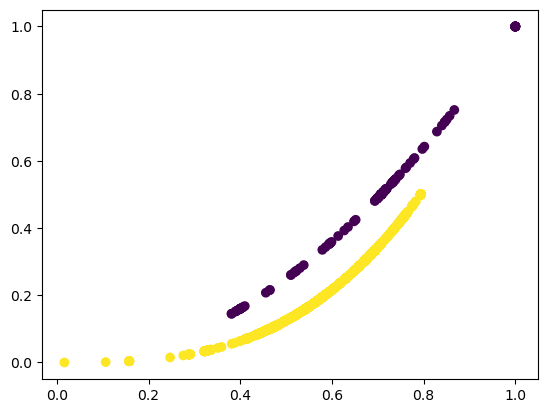

In [25]:
import matplotlib.pyplot as plt
plt.scatter(VOL_df['characteristic_length_ratio'], VOL_df['packing_fraction'], c=VOL_df['dimension'])

In [13]:
rows_with_nan = VOL_df[VOL_df.isna().any(axis=1)]
rows_with_nan

,filename,avg_hull_volume,avg_hull_area,unitcell_volume,motif_unitcell_ratio
1208,POSCAR_C2Pd2_1,NaN,NaN,41.154290,NaN
1209,POSCAR_C2Ru2_5,NaN,NaN,42.304149,NaN
1227,POSCAR_C4Mn2_1,NaN,NaN,60.857746,NaN
1228,POSCAR_C4Mn2_1_st025,NaN,NaN,65.537136,NaN
1229,POSCAR_C4Mn2_1_st050,NaN,NaN,70.450448,NaN
1230,POSCAR_C4Mn2_1_st950,NaN,NaN,52.177910,NaN
1231,POSCAR_C4Mn2_1_st975,NaN,NaN,56.406573,NaN
3165,POSCAR_Fe2N2_3,NaN,NaN,52.473901,NaN
3166,POSCAR_Fe2N2_3_st025,NaN,NaN,56.508652,NaN
3167,POSCAR_Fe2N2_3_st050,NaN,NaN,60.745100,NaN


In [35]:
import os
import glob
import numpy as np
import pandas as pd
from pymatgen.core import Structure
from pymatgen.analysis.local_env import CrystalNN
from scipy.spatial.distance import pdist

# ===== 사용자 환경에 맞게 설정 =====
# 자성 원소 리스트(예시). 프로젝트에 맞게 수정하세요.
magnetic_species = {"Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn", "Y", "Zr", "Nb", "Mo", "Ru", "Rh", "Pd", "Ag", "Cd"}
# 파일 패턴: 필요시 "CONTCAR*" 또는 경로 포함 패턴으로 변경
FILE_PATTERN = os.path.join("", "POSCAR_*")
# 모티프에서 선택할 비자성 이웃 최대 개수
NUM_NEIGHBORS = 12
# ==================================

def find_motifs(contcar_file, magnetic_species, num_neighbors):
    """
    POSCAR/CONTCAR 파일에서 두 개의 자성원자 중심 motif를 추출합니다.
    
    각 motif는 다음을 포함합니다:
      - center_coord: 중심 자성원의 좌표 (절대좌표)
      - motif_coords: 중심 자성원자 기준의 비자성 이웃 좌표(상대좌표, centered)
      - selected_neighbor_indices: 선택된 비자성 이웃의 원래 인덱스
      - distances: 중심과 각 이웃 사이의 거리
    """
    structure = Structure.from_file(contcar_file)
    
    # 자성원자 인덱스 추출
    magnetic_indices = [i for i, site in enumerate(structure) if str(site.specie) in magnetic_species]
    if len(magnetic_indices) < 2:
        raise ValueError("파일에 자성원자가 2개 미만입니다.")
    
    # 2개 이상의 자성원자가 있을 경우 처음 두 개만 사용
    magnetic_indices = magnetic_indices[:2]
    
    cnn = CrystalNN()
    motifs = {}
    
    for mag_index in magnetic_indices:
        center_site = structure[mag_index]
        nn_info = cnn.get_nn_info(structure, mag_index)
        
        # 비자성 이웃만 선택
        nonmag_neighbors = []
        nonmag_neighbor_indices = []
        for info in nn_info:
            neighbor_index = info.get("site_index", None)
            neighbor_site = info["site"]
            if str(neighbor_site.specie) not in magnetic_species:
                nonmag_neighbors.append(neighbor_site.coords)
                nonmag_neighbor_indices.append(neighbor_index)
        
        nonmag_neighbors = np.array(nonmag_neighbors, dtype=float)
        
        if nonmag_neighbors.shape[0] == 0:
            raise ValueError(f"자성원자 index {mag_index} 주변에 비자성 이웃이 없습니다.")
        
        # 중심과의 거리를 계산하여 가장 가까운 이웃들을 선택
        distances = np.linalg.norm(nonmag_neighbors - center_site.coords, axis=1)
        actual_neighbors = min(num_neighbors, nonmag_neighbors.shape[0])
        sorted_idx = np.argsort(distances)[:actual_neighbors]
        selected_neighbors = nonmag_neighbors[sorted_idx]
        selected_indices = [nonmag_neighbor_indices[i] for i in sorted_idx]
        selected_distances = distances[sorted_idx]
        
        # 중심 좌표를 빼서 중심(자성 원자) 기준 상대 좌표 계산
        motif_coords = selected_neighbors - center_site.coords
        
        motifs[mag_index] = {
            "center_coord": center_site.coords,
            "motif_coords": motif_coords,
            "selected_neighbor_indices": selected_indices,
            "distances": selected_distances
        }
    
    return motifs

def sort_motif_by_neighbor_indices(motif):
    """
    motif 내에서 'selected_neighbor_indices'를 기준으로 오름차순 정렬하고,
    그에 맞게 'motif_coords'와 'distances'도 재정렬합니다.
    """
    sel_idx = np.array(motif["selected_neighbor_indices"])
    order = np.argsort(sel_idx)
    motif["selected_neighbor_indices"] = sel_idx[order].tolist()
    motif["motif_coords"] = motif["motif_coords"][order]
    motif["distances"] = motif["distances"][order]
    return motif

def compute_motif_axis_features(motif):
    """
    motif 내 비자성 이웃들 간의 모든 pairwise 거리를 계산하여,
    가장 긴 거리(장축), 가장 짧은 거리(단축), axis_ratio(장축/단축)를 반환합니다.
    점이 2개 미만이면 None 반환.
    """
    points = motif["motif_coords"]
    if points.shape[0] < 2:
        return {"long_axis": None, "short_axis": None, "axis_ratio": None}
    
    pairwise_distances = pdist(points, metric='euclidean')
    long_axis = float(pairwise_distances.max())
    short_axis = float(pairwise_distances.min())
    axis_ratio = (long_axis / short_axis) if short_axis != 0 else np.nan
    
    return {"long_axis": long_axis, "short_axis": short_axis, "axis_ratio": axis_ratio}

def compute_motif_s_delta(motif, eps=1e-12):
    """
    주어진 motif에 대해 형상 왜곡 크기 s와 오프센터 크기 delta를 계산합니다.
    
    정의:
      - C = 리간드 중심(평균) 좌표
      - r_i = 각 리간드의 C로부터의 거리
      - rbar = r_i의 평균
      - s = std(r_i) / rbar
      - delta = || r_M - C || / rbar
        (motif_coords가 중심 기준 상대좌표이므로, delta = ||mean(motif_coords)|| / rbar)
    """
    P = np.asarray(motif["motif_coords"], dtype=float)  # (N,3) 중심 기준 상대좌표
    if P.shape[0] < 2:
        return {"s": None, "delta": None, "rbar": None, "n_neighbors": int(P.shape[0])}

    # 리간드 평균(상대좌표계에서 평균 벡터)
    mu = P.mean(axis=0)  # (3,)

    # 리간드 중심으로부터의 반지름들 (상대좌표만으로 계산 가능)
    r = np.linalg.norm(P - mu, axis=1)  # (N,)
    rbar = float(r.mean())
    if rbar < eps:
        return {"s": np.nan, "delta": np.nan, "rbar": rbar, "n_neighbors": int(P.shape[0])}

    s = float(r.std(ddof=0) / rbar)
    delta = float(np.linalg.norm(mu) / rbar)

    return {"s": s, "delta": delta, "rbar": rbar, "n_neighbors": int(P.shape[0])}

# ===================== 메인 루프 =====================
data_list = []

# 파일 목록 수집
contcar_files = glob.glob(FILE_PATTERN)
file_list = [f.replace(os.sep, "/") for f in contcar_files]

for contcar_file in file_list:
    try:
        motifs = find_motifs(contcar_file, magnetic_species=magnetic_species, num_neighbors=NUM_NEIGHBORS)
    except Exception:
        continue  # 에러 발생 시 건너뜁니다.
    
    keys = list(motifs.keys())
    if len(keys) < 2:
        continue  # 자성원자가 2개 미만인 경우 건너뜁니다.
    
    # 첫 두 자성원자에 대한 motif 정렬
    motif0 = sort_motif_by_neighbor_indices(motifs[keys[0]])
    motif1 = sort_motif_by_neighbor_indices(motifs[keys[1]])
    
    # 축 특징 계산
    axis_features0 = compute_motif_axis_features(motif0)
    axis_features1 = compute_motif_axis_features(motif1)
    
    combined_axis = {}
    if axis_features0["long_axis"] is not None and axis_features1["long_axis"] is not None:
        combined_axis["avg_long_axis"] = (axis_features0["long_axis"] + axis_features1["long_axis"]) / 2.0
    else:
        combined_axis["avg_long_axis"] = None
    if axis_features0["short_axis"] is not None and axis_features1["short_axis"] is not None:
        combined_axis["avg_short_axis"] = (axis_features0["short_axis"] + axis_features1["short_axis"]) / 2.0
    else:
        combined_axis["avg_short_axis"] = None
    if axis_features0["axis_ratio"] is not None and axis_features1["axis_ratio"] is not None:
        combined_axis["avg_axis_ratio"] = (axis_features0["axis_ratio"] + axis_features1["axis_ratio"]) / 2.0
    else:
        combined_axis["avg_axis_ratio"] = None

    # s, delta 계산 (두 자성원자 각각)
    sd0 = compute_motif_s_delta(motif0)
    sd1 = compute_motif_s_delta(motif1)

    combined_sd = {}
    if (sd0["s"] is not None and sd1["s"] is not None):
        combined_sd["avg_s"] = (sd0["s"] + sd1["s"]) / 2.0
    else:
        combined_sd["avg_s"] = None

    if (sd0["delta"] is not None and sd1["delta"] is not None):
        combined_sd["avg_delta"] = (sd0["delta"] + sd1["delta"]) / 2.0
    else:
        combined_sd["avg_delta"] = None

    # (선택) 개별 값도 보고 싶다면 주석 해제
    # combined_sd.update({
    #     "s_motif0": sd0["s"], "delta_motif0": sd0["delta"],
    #     "s_motif1": sd1["s"], "delta_motif1": sd1["delta"]
    # })

    file_data = {"filename": contcar_file}
    file_data.update(combined_axis)
    file_data.update(combined_sd)
    data_list.append(file_data)

# DataFrame 생성
ELONG_df = pd.DataFrame(data_list)
ELONG_df

c:\Users\JKC\anaconda3\Lib\site-packages\pymatgen\analysis\local_env.py:4021: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r1 = _get_radius(structure[n])
c:\Users\JKC\anaconda3\Lib\site-packages\pymatgen\analysis\local_env.py:4023: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r2 = _get_radius(entry["site"])
c:\Users\JKC\anaconda3\Lib\site-packages\pymatgen\analysis\local_env.py:3935: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  nn_data = self.get_nn_data(structure, n)


,filename,avg_long_axis,avg_short_axis,avg_axis_ratio,avg_s,avg_delta
0,POSCAR_Ag2F6_3,4.141935,2.892687,1.431870,0.004466,0.000522
1,POSCAR_Ag2F6_3_st025,4.245483,2.965004,1.431870,0.004466,0.000522
2,POSCAR_Ag2F6_3_st050,4.349032,3.037321,1.431870,0.004466,0.000522
3,POSCAR_Ag2F6_3_st950,3.934838,2.748053,1.431870,0.004466,0.000522
4,POSCAR_Ag2F6_3_st975,4.038387,2.820370,1.431870,0.004466,0.000522
...,...,...,...,...,...,...
5940,POSCAR_Tl2Zr2_1_z025,6.331740,3.518708,1.799451,0.000217,0.000737
5941,POSCAR_Tl2Zr2_1_z050,6.422573,3.518708,1.825265,0.000211,0.000727
5942,POSCAR_Tl2Zr2_1_z950,6.064892,3.518708,1.723614,0.000236,0.000769
5943,POSCAR_Tl2Zr2_1_z975,6.152859,3.518708,1.748613,0.000229,0.000758


In [15]:
rows_with_nan = ELONG_df[ELONG_df.isna().any(axis=1)]
rows_with_nan

,filename,avg_long_axis,avg_short_axis,avg_axis_ratio,avg_s,avg_delta
1208,POSCAR_C2Pd2_1,NaN,NaN,NaN,NaN,NaN
3165,POSCAR_Fe2N2_3,NaN,NaN,NaN,NaN,NaN
3166,POSCAR_Fe2N2_3_st025,NaN,NaN,NaN,NaN,NaN
3167,POSCAR_Fe2N2_3_st050,NaN,NaN,NaN,NaN,NaN
3168,POSCAR_Fe2N2_3_st950,NaN,NaN,NaN,NaN,NaN
3169,POSCAR_Fe2N2_3_st975,NaN,NaN,NaN,NaN,NaN
4725,POSCAR_N2Rh2_5,NaN,NaN,NaN,NaN,NaN


In [3]:
import os
import glob
import numpy as np
import pandas as pd
from pymatgen.core import Structure
from pymatgen.analysis.local_env import CrystalNN

def find_motifs(contcar_file, magnetic_species, num_neighbors):
    """
    CONTCAR 파일에서 두 개의 자성원자 중심 motif를 추출합니다.
    
    각 motif에는 다음 정보가 포함됩니다:
      - center_coord: 중심 자성원의 좌표
      - magnetic_atom_info: 중심 자성원의 원자번호와 전기음성도
      - motif_coords: 중심 원자를 기준으로 한, 선택된 비자성원자들의 상대 좌표
      - selected_neighbor_indices: 선택된 비자성원자의 원래 인덱스
      - distances: 중심과 각 이웃 사이의 거리
      - nonmagnetic_atoms_info: 각 선택된 비자성원자의 원자번호와 전기음성도
      - num_nonmagnetic_atoms: motif 내 선택된 비자성원자의 개수
    """
    structure = Structure.from_file(contcar_file)
    
    # 자성원자 인덱스 추출
    magnetic_indices = [i for i, site in enumerate(structure) if str(site.specie) in magnetic_species]
    if len(magnetic_indices) < 2:
        raise ValueError("CONTCAR에 자성원자가 2개 미만입니다.")
    
    # 자성원자가 2개 이상이면 처음 두 개만 사용
    magnetic_indices = magnetic_indices[:2]
    
    cnn = CrystalNN()
    motifs = {}
    
    for mag_index in magnetic_indices:
        center_site = structure[mag_index]
        center_species = center_site.specie
        magnetic_atom_info = {"atomic_number": center_species.Z, "electronegativity": center_species.X}
        
        nn_info = cnn.get_nn_info(structure, mag_index)
        
        # 비자성원자 선택 (자성원소 리스트에 포함되지 않는 원소)
        nonmag_neighbors = []
        nonmag_neighbor_indices = []
        nonmag_neighbors_species = []
        for info in nn_info:
            neighbor_index = info.get("site_index", None)
            neighbor_site = info["site"]
            if str(neighbor_site.specie) not in magnetic_species:
                nonmag_neighbors.append(neighbor_site.coords)
                nonmag_neighbor_indices.append(neighbor_index)
                nonmag_neighbors_species.append(neighbor_site.specie)
        
        nonmag_neighbors = np.array(nonmag_neighbors)
        
        if nonmag_neighbors.shape[0] == 0:
            raise ValueError(f"자성원자 index {mag_index} 주변에 비자성원이 없습니다.")
        
        # 중심과의 거리를 계산하여 가장 가까운 이웃들을 선택
        distances = np.linalg.norm(nonmag_neighbors - center_site.coords, axis=1)
        actual_neighbors = min(num_neighbors, nonmag_neighbors.shape[0])
        sorted_idx = np.argsort(distances)[:actual_neighbors]
        selected_neighbors = nonmag_neighbors[sorted_idx]
        selected_indices = [nonmag_neighbor_indices[i] for i in sorted_idx]
        selected_distances = distances[sorted_idx]
        selected_neighbors_species = [nonmag_neighbors_species[i] for i in sorted_idx]
        # 비자성원자 종류가 1개라고 가정하므로, 첫 번째 원소의 정보를 사용
        nonmag_atoms_info = [{"atomic_number": selected_neighbors_species[0].Z,
                              "electronegativity": selected_neighbors_species[0].X}]
        
        # 중심 좌표를 빼서 중심화된 상대 좌표 계산 (필요 시 활용)
        motif_coords = selected_neighbors - center_site.coords
        
        num_nonmagnetic_atoms = len(selected_indices)
        
        motifs[mag_index] = {
            "center_coord": center_site.coords,
            "magnetic_atom_info": magnetic_atom_info,
            "motif_coords": motif_coords,
            "selected_neighbor_indices": selected_indices,
            "distances": selected_distances,
            "nonmagnetic_atoms_info": nonmag_atoms_info,
            "num_nonmagnetic_atoms": num_nonmagnetic_atoms
        }
    
    return motifs

def sort_motif_by_neighbor_indices(motif):
    """
    motif 내에서 'selected_neighbor_indices'를 기준으로 오름차순 정렬하고,
    그 순서에 맞게 'motif_coords', 'distances', 'nonmagnetic_atoms_info'를 재정렬합니다.
    """
    sel_idx = np.array(motif["selected_neighbor_indices"])
    order = np.argsort(sel_idx)
    motif["selected_neighbor_indices"] = sel_idx[order].tolist()
    motif["motif_coords"] = motif["motif_coords"][order]
    motif["distances"] = motif["distances"][order]
    # 비자성원자의 종류는 1개이므로 재정렬은 생략해도 무방
    return motif

# DataFrame 생성: 각 파일별로 계산된 정보를 수집합니다.
data_list = []

# CONTCAR 파일 목록 (파일명 패턴은 환경에 맞게 수정)
contcar_files = glob.glob(os.path.join("", "POSCAR_*"))
file_list = [f.replace(os.sep, "/") for f in contcar_files]

for contcar_file in file_list:
    try:
        motifs = find_motifs(contcar_file, magnetic_species=magnetic_species, num_neighbors=12)
    except Exception:
        continue  # 에러 발생 시 해당 파일 건너뜁니다.
    
    keys = list(motifs.keys())
    if len(keys) < 2:
        continue  # 자성원자가 2개 미만이면 건너뜁니다.
    
    # 두 자성원자에 대한 motif 데이터를 정렬합니다.
    motif0 = sort_motif_by_neighbor_indices(motifs[keys[0]])
    motif1 = sort_motif_by_neighbor_indices(motifs[keys[1]])
    
    # 자성원자 정보는 두 모티프 모두 동일하다고 가정합니다.
    mag_info = motif0["magnetic_atom_info"]
    # 비자성원자 정보: 종류가 1개라 가정하므로 motif0의 첫 번째 비자성원자 정보를 사용합니다.
    nonmag_info = motif0["nonmagnetic_atoms_info"][0]
    
    # 각 모티프에 포함된 비자성원자 개수
    count_motif0 = motif0["num_nonmagnetic_atoms"]
    count_motif1 = motif1["num_nonmagnetic_atoms"]
    
    # 각 파일에 대한 정보를 하나의 행(row)으로 수집합니다.
    file_data = {
        "filename": contcar_file,
        "motif0_nonmag_count": count_motif0,
        "motif1_nonmag_count": count_motif1,
        "magnetic_atomic_number": mag_info["atomic_number"],
        "magnetic_electronegativity": mag_info["electronegativity"],
        "nonmagnetic_atomic_number": nonmag_info["atomic_number"],
        "nonmagnetic_electronegativity": nonmag_info["electronegativity"]
    }
    data_list.append(file_data)

# DataFrame 생성 (출력 없이 변수 df에 저장)
ATOM_df = pd.DataFrame(data_list)
ATOM_df

""


In [4]:
ATOM_df

""


In [17]:
rows_with_nan = ATOM_df[ATOM_df.isna().any(axis=1)]
rows_with_nan

,filename,motif0_nonmag_count,motif1_nonmag_count,magnetic_atomic_number,magnetic_electronegativity,nonmagnetic_atomic_number,nonmagnetic_electronegativity


In [37]:
import os
import glob
import numpy as np
import pandas as pd
from pymatgen.core import Structure
from pymatgen.analysis.local_env import CrystalNN
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import pdist, cdist  # cdist 추가 (헝가리안 매칭용)

# (이전 함수 정의는 동일하므로 생략)

def _relative_vector_with_pbc(structure, center_index, nn_info):
    """
    CrystalNN.get_nn_info()의 항목(nn_info)에서 중심-이웃 최소 이미지(relative) 벡터(Å)를 계산합니다.
    """
    jimg = nn_info.get("image", (0, 0, 0))
    if jimg is None:
        jimg = (0, 0, 0)
    jimg = np.array(jimg, dtype=int)
    nbr_idx = nn_info.get("site_index", None)
    if nbr_idx is None:
        return None

    f_center = structure[center_index].frac_coords
    f_nbr = structure[nbr_idx].frac_coords + jimg
    f_vec = f_nbr - f_center
    # 분수좌표 벡터를 카르테시안으로 변환
    rel_cart = structure.lattice.get_cartesian_coords(f_vec)
    return rel_cart

def find_motifs(contcar_file, magnetic_species=None, r_cut=3.0, num_neighbors=12):
    """
    CONTCAR 파일에서 두 개의 자성원자 중심 motif를 추출합니다.
    (PBC를 고려하여 중심-이웃 상대 벡터를 계산하도록 수정)
    """
    structure = Structure.from_file(contcar_file)
    
    # 자성원자에 해당하는 site 인덱스 찾기
    magnetic_indices = [i for i, site in enumerate(structure) if str(site.specie) in magnetic_species]
    if len(magnetic_indices) < 2:
        raise ValueError("CONTCAR에 자성원자가 2개 미만입니다.")
    
    # 자성원자가 2개보다 많으면 처음 두 개만 사용
    magnetic_indices = magnetic_indices[:2]
    
    cnn = CrystalNN()
    motifs = {}
    
    for mag_index in magnetic_indices:
        center_site = structure[mag_index]
        nn_info_list = cnn.get_nn_info(structure, mag_index)
        
        # 비자성원자만 선택 (자성원소 리스트에 포함되지 않는 원소)
        rel_vectors = []               # 중심 기준 상대 벡터(Å) - PBC 최소 이미지
        nonmag_neighbor_indices = []   # 대응되는 이웃의 site 인덱스
        distances = []                 # 상대 벡터의 노름(거리)
        
        for info in nn_info_list:
            neighbor_index = info.get("site_index", None)
            if neighbor_index is None:
                continue
            
            neighbor_site = structure[neighbor_index]
            if str(neighbor_site.specie) in magnetic_species:
                continue  # 비자성 이웃만
            
            # === PBC 반영: 최소 이미지(relative) 벡터 계산 ===
            rel_vec = _relative_vector_with_pbc(structure, mag_index, info)
            if rel_vec is None:
                continue
            rel_vectors.append(rel_vec)
            nonmag_neighbor_indices.append(neighbor_index)
            distances.append(np.linalg.norm(rel_vec))
        
        if len(rel_vectors) == 0:
            raise ValueError(f"자성원자 index {mag_index} 주변에 비자성원이 없습니다.")
        
        rel_vectors = np.array(rel_vectors)
        distances = np.array(distances)
        
        # 중심과의 거리를 기준으로 가장 가까운 이웃들을 선택합니다.
        actual_neighbors = min(num_neighbors, rel_vectors.shape[0])
        sorted_idx = np.argsort(distances)[:actual_neighbors]
        
        selected_rel_vectors = rel_vectors[sorted_idx]               # 이미 중심화된 상대 좌표
        selected_indices = [nonmag_neighbor_indices[i] for i in sorted_idx]
        selected_distances = distances[sorted_idx]
        
        # motif_coords는 이미 중심화된 상대 좌표(Å)
        motif_coords = selected_rel_vectors
        
        motifs[mag_index] = {
            "center_coord": center_site.coords,
            "motif_coords": motif_coords,
            "selected_neighbor_indices": selected_indices,
            "distances": selected_distances
        }
    
    return motifs

def sort_motif_by_neighbor_indices(motif):
    """
    motif 딕셔너리 내에서 'selected_neighbor_indices'를 기준으로 오름차순 정렬하고,
    그에 맞게 'motif_coords'와 'distances'도 재정렬합니다.
    (원본을 수정하지 않고 사본을 반환하도록 변경)
    """
    sel_idx = np.array(motif["selected_neighbor_indices"])
    order = np.argsort(sel_idx)

    # 부수효과 없는 사본 반환
    return {
        "center_coord": np.array(motif["center_coord"]).copy(),
        "motif_coords": motif["motif_coords"][order].copy(),
        "selected_neighbor_indices": sel_idx[order].tolist(),
        "distances": motif["distances"][order].copy()
    }

def kabsch_rotation(P, Q):
    """
    두 점 집합 P와 Q (각각 shape (N, 3))에 대해 Kabsch 알고리즘을 적용하여 최적의 회전 행렬 R을 구합니다.
    (함수 내용은 원본과 동일)
    """
    C = np.dot(P.T, Q)  # 공분산 행렬
    V, S, Wt = np.linalg.svd(C)
    d = np.linalg.det(np.dot(Wt.T, V.T))
    D = np.eye(3)
    D[2, 2] = d
    R = np.dot(np.dot(Wt.T, D), V.T)
    return R

def rotation_angle_from_matrix(R):
    """
    회전 행렬 R (3×3)로부터 회전 각도(theta)를 계산합니다.
    (함수 내용은 원본과 동일)
    """
    trace = np.trace(R)
    cos_theta = np.clip((trace - 1) / 2, -1.0, 1.0)
    theta = np.arccos(cos_theta)
    return theta

# === 헝가리안 매칭 기반의 견고한 회전각 계산 추가 ===
def rotation_angle_with_assignment(P, Q, max_iter=8, tol=1e-10):
    """
    P, Q: (N, 3) 중심 기준 상대 좌표(Å).
    1) 초기 Kabsch
    2) P를 회전한 뒤 Q와의 제곱거리 비용행렬로 헝가리안 매칭
    3) 매칭된 쌍으로 Kabsch 갱신
    반복 수렴 후 최종 회전각(도) 반환
    """
    n = min(len(P), len(Q))
    if n < 3:
        raise ValueError("회전을 안정적으로 구하려면 최소 3개 이상의 이웃이 필요합니다.")
    P0 = np.asarray(P[:n], float)
    Q0 = np.asarray(Q[:n], float)

    # 초기 회전 추정
    R = kabsch_rotation(P0, Q0)
    for _ in range(max_iter):
        # P를 회전하여 Q와의 비용행렬 계산 (sqeuclidean)
        P_rot = P0 @ R
        C = cdist(P_rot, Q0, metric="sqeuclidean")
        row, col = linear_sum_assignment(C)

        R_new = kabsch_rotation(P0[row], Q0[col])
        if np.linalg.norm(R_new - R) < tol:
            R = R_new
            break
        R = R_new

    theta_deg = np.degrees(rotation_angle_from_matrix(R))
    return theta_deg

# DataFrame 생성: 각 파일의 회전 각도를 딕셔너리 형태로 수집합니다.
results = []

# CONTCAR 파일 목록 (환경에 맞게 수정)
contcar_files = glob.glob(os.path.join("", "POSCAR_*"))
file_list = [f.replace(os.sep, "/") for f in contcar_files]

for contcar_file in file_list:
    try:
        motifs = find_motifs(
            contcar_file,
            magnetic_species=["Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn", "Y", "Zr", "Nb", "Mo", "Ru", "Rh", "Pd", "Ag", "Cd"],
            num_neighbors=12
        )
        keys = list(motifs.keys())
        if len(keys) < 2:
            continue
        
        motif0_orig = motifs[keys[0]]
        motif1_orig = motifs[keys[1]]
        
        # --- Kabsch 알고리즘을 위해 두 motif의 원자 개수를 동일하게 맞춰줍니다 ---
        min_len = min(len(motif0_orig['motif_coords']), len(motif1_orig['motif_coords']))
        
        # === 3개 미만 이웃은 스킵 ===
        if min_len < 3:
            continue  # 회전 정의가 불안정 → 해당 파일 건너뜀
        
        # ======================= 코드 변경/추가 부분 시작 =======================
        # 1. 인덱스를 고려하지 않는 계산 (거리순 정렬, 기하학적 형태 비교)
        # find_motifs의 결과는 이미 거리순으로 정렬되어 있으므로 그대로 사용합니다.
        coords0_dist = motif0_orig['motif_coords'][:min_len]
        coords1_dist = motif1_orig['motif_coords'][:min_len]

        # 3. 헝가리안 매칭을 활용한 견고한 회전각
        angle_deg_hungarian = rotation_angle_with_assignment(coords0_dist, coords1_dist)
        
        # 최종 결과에 세 종류의 각도를 모두 추가합니다.
        results.append({
            "filename": contcar_file,
            "hungarian_rotation_angle_deg": angle_deg_hungarian
        })
        # ======================= 코드 변경/추가 부분 끝 =========================
        
    except Exception:
        continue

# DataFrame 생성 (출력 없이 df 변수에 저장)
ROT_df = pd.DataFrame(results)
ROT_df

c:\Users\JKC\anaconda3\Lib\site-packages\pymatgen\analysis\local_env.py:4021: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r1 = _get_radius(structure[n])
c:\Users\JKC\anaconda3\Lib\site-packages\pymatgen\analysis\local_env.py:4023: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r2 = _get_radius(entry["site"])
c:\Users\JKC\anaconda3\Lib\site-packages\pymatgen\analysis\local_env.py:3935: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  nn_data = self.get_nn_data(structure, n)


,filename,hungarian_rotation_angle_deg
0,POSCAR_Ag2F6_3,95.584214
1,POSCAR_Ag2F6_3_st025,95.584214
2,POSCAR_Ag2F6_3_st050,95.584214
3,POSCAR_Ag2F6_3_st950,95.584214
4,POSCAR_Ag2F6_3_st975,95.584214
...,...,...
5926,POSCAR_Tl2Zr2_1_z025,147.648265
5927,POSCAR_Tl2Zr2_1_z050,147.744496
5928,POSCAR_Tl2Zr2_1_z950,111.405210
5929,POSCAR_Tl2Zr2_1_z975,111.618672


In [1]:
import os
import glob
import numpy as np
import pandas as pd
from pymatgen.core import Structure
from pymatgen.analysis.local_env import CrystalNN
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def find_motifs(contcar_file, magnetic_species=None, num_neighbors=12):
    """
    CONTCAR 파일에서 두 개의 자성원자 중심 motif를 추출합니다.
    (PBC가 자동으로 고려됩니다.)
    """
    structure = Structure.from_file(contcar_file)
    if magnetic_species is None:
        magnetic_species = ["Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn", 
                            "Y", "Zr", "Nb", "Mo", "Ru", "Rh", "Pd", "Ag", "Cd"]
    
    magnetic_indices = [i for i, site in enumerate(structure) if str(site.specie) in magnetic_species]
    if len(magnetic_indices) < 2:
        raise ValueError("파일에 자성원자가 2개 미만입니다.")
    
    magnetic_indices = magnetic_indices[:2]
    
    cnn = CrystalNN()
    motifs = {}
    
    for mag_index in magnetic_indices:
        center_site = structure[mag_index]
        nn_info = cnn.get_nn_info(structure, mag_index)
        
        nonmag_neighbors_coords = np.array([
            info["site"].coords for info in nn_info 
            if str(info["site"].specie) not in magnetic_species
        ])
        
        if nonmag_neighbors_coords.shape[0] == 0:
            raise ValueError(f"자성원자 index {mag_index} 주변에 비자성 이웃이 없습니다.")
        
        distances = np.linalg.norm(nonmag_neighbors_coords - center_site.coords, axis=1)
        actual_neighbors = min(num_neighbors, nonmag_neighbors_coords.shape[0])
        sorted_indices = np.argsort(distances)[:actual_neighbors]
        
        selected_neighbors_coords = nonmag_neighbors_coords[sorted_indices]
        motif_coords = selected_neighbors_coords - center_site.coords
        
        # 평균 M-X 결합길이 계산 (ℓ₀)
        selected_distances = distances[sorted_indices]
        avg_bond_length = np.mean(selected_distances)
        
        motifs[mag_index] = {
            "motif_coords": motif_coords,
            "avg_bond_length": avg_bond_length  # ℓ₀ 저장
        }
    
    return motifs

def calculate_rmsd_and_std_with_assignment(p_coords, q_coords):
    """
    두 모티프(P, Q) 간의 최적 RMSD와 거리의 표준편차를 계산합니다.
    (회전 정렬 없이, 주어진 방향 그대로 비교합니다.)
    """
    cost_matrix = cdist(p_coords, q_coords, 'sqeuclidean')
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    optimal_squared_dists = cost_matrix[row_ind, col_ind]
    rmsd = np.sqrt(np.mean(optimal_squared_dists))
    
    optimal_dists = np.sqrt(optimal_squared_dists)
    std = np.std(optimal_dists)
    
    return rmsd, std

def calculate_p_breaking_metric(motif1_coords, motif2_coords, l0_motif1, l0_motif2):
    """
    두 모티프 좌표를 받아 P-symmetry breaking metric과 관련 std를 계산합니다.
    수식: feat_x = D̄_p × D̄_i = (D_p/ℓ₀) × (D_i/ℓ₀)
    """
    if motif1_coords.shape[0] != motif2_coords.shape[0]:
        raise ValueError("두 모티프의 비자성원자 개수가 일치하지 않습니다.")
        
    # 시나리오 1: Identity (그대로 비교)
    rmsd_identity, std_identity = calculate_rmsd_and_std_with_assignment(motif1_coords, motif2_coords)
    
    # 시나리오 2: Inversion (원점 대칭 후 비교)
    motif1_coords_inverted = -motif1_coords
    rmsd_inversion, std_inversion = calculate_rmsd_and_std_with_assignment(motif1_coords_inverted, motif2_coords)

    # 평균 결합길이로 정규화
    # D̄_p = D_p / ℓ₀, D̄_i = D_i / ℓ₀
    avg_l0 = (l0_motif1 + l0_motif2) / 2  # 두 motif의 평균 ℓ₀ 사용
    
    normalized_rmsd_identity = rmsd_identity / avg_l0
    normalized_rmsd_inversion = rmsd_inversion / avg_l0
    
    # P-breaking metric: D̄_p × D̄_i
    p_metric = normalized_rmsd_identity * normalized_rmsd_inversion
    
    if rmsd_identity <= rmsd_inversion:
        p_metric_std = std_identity / avg_l0
        is_inversion_symmetric = 0
    else:
        p_metric_std = std_inversion / avg_l0
        is_inversion_symmetric = 1

    return p_metric, p_metric_std, is_inversion_symmetric

# ==============================================================================
# 메인 실행 스크립트
# ==============================================================================
def main():
    search_path = ""
    file_pattern = "POSCAR_*"
    results = []

    contcar_files = glob.glob(os.path.join(search_path, file_pattern))
    file_list = [f.replace(os.sep, "/") for f in contcar_files]
    print(f"총 {len(file_list)}개의 파일을 분석합니다...")

    for contcar_file in file_list:
        try:
            motifs = find_motifs(contcar_file, num_neighbors=12)
            keys = list(motifs.keys())
            
            motif0_coords = motifs[keys[0]]["motif_coords"]
            motif1_coords = motifs[keys[1]]["motif_coords"]
            l0_motif0 = motifs[keys[0]]["avg_bond_length"]
            l0_motif1 = motifs[keys[1]]["avg_bond_length"]
            
            p_metric, p_metric_std, is_inv = calculate_p_breaking_metric(
                motif0_coords, motif1_coords, l0_motif0, l0_motif1
            )
            
            results.append({
                "filename": contcar_file,
                "p_metric": p_metric,
                "p_metric_std": p_metric_std,
                "avg_bond_length_motif0": l0_motif0,
                "avg_bond_length_motif1": l0_motif1
            })
        except Exception as e:
            print(f" (!) 파일 {contcar_file} 처리 중 오류 발생: {e}")
            continue

    if results:
        df = pd.DataFrame(results)
        print("\n✅ 분석 완료! DataFrame이 생성되었습니다.")
        return df
    else:
        print("\n❌ 처리할 파일이 없거나 모든 파일에서 오류가 발생했습니다.")
        return pd.DataFrame()

if __name__ == "__main__":
    P_METRIC_df = main()
    if not P_METRIC_df.empty:
        print("\n--- 생성된 DataFrame 미리보기 ---")
P_METRIC_df

총 6개의 파일을 분석합니다...

✅ 분석 완료! DataFrame이 생성되었습니다.

--- 생성된 DataFrame 미리보기 ---


c:\Users\JKC\anaconda3\Lib\site-packages\pymatgen\analysis\local_env.py:4021: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r1 = _get_radius(structure[n])
c:\Users\JKC\anaconda3\Lib\site-packages\pymatgen\analysis\local_env.py:4023: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r2 = _get_radius(entry["site"])
c:\Users\JKC\anaconda3\Lib\site-packages\pymatgen\analysis\local_env.py:3935: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  nn_data = self.get_nn_data(structure, n)


,filename,p_metric,p_metric_std,avg_bond_length_motif0,avg_bond_length_motif1
0,POSCAR_CoO,0.811746,0.002115,1.979691,1.979254
1,POSCAR_CoS,0.689297,0.000673,2.505815,2.505896
2,POSCAR_CrS,0.667790,0.009496,2.665062,2.665441
3,POSCAR_FeAs,0.690114,0.000752,2.606398,2.606578
4,POSCAR_FeS,0.870780,0.002319,2.342133,2.342575
5,POSCAR_NiS,0.681629,0.000338,2.459540,2.459496


In [7]:
P_METRIC_df.describe()

,p_metric,p_metric_std,avg_bond_length_motif0,avg_bond_length_motif1
count,5.926000e+03,5926.000000,5926.000000,5926.000000
mean,3.793492e-01,0.059563,2.553100,2.553793
std,3.120027e-01,0.114013,0.372404,0.372242
min,1.453517e-09,0.000000,1.723675,1.723728
25%,2.850845e-03,0.000631,2.209559,2.209699
50%,4.143892e-01,0.008033,2.606859,2.607532
75%,6.768675e-01,0.055430,2.860161,2.859972
max,1.436582e+00,0.553158,3.549821,3.550015


In [9]:
P_METRIC_df[P_METRIC_df['p_metric']<0.001]

,filename,p_metric,p_metric_std,is_inversion_symmetric
43,POSCAR_Al2Cr2_3,0.000119,8.400500e-06,0
45,POSCAR_Al2Cr2_5,0.000565,6.253810e-16,1
84,POSCAR_Al2Mn2_6,0.000805,2.856811e-16,1
87,POSCAR_Al2Mo2_4,0.000344,6.525784e-05,0
89,POSCAR_Al2Ru2_1,0.000450,1.000346e-06,0
...,...,...,...,...
5685,POSCAR_S2Ti2_4,0.000468,9.049306e-06,1
5738,POSCAR_S2Y2_1,0.000779,2.541101e-05,1
5845,POSCAR_Si2Ti2_1,0.000177,6.684962e-05,0
5847,POSCAR_Si2V2_3,0.000118,1.123747e-05,0


In [39]:
Hubbard_U = {"21": 3, "22": 3, "23": 4, "24": 4 , "25": 4, "26": 4, "27": 3, "28": 7, "29": 7, "30": 7, "39": 3, "40": 3, "41": 4, "42": 4, "44": 4, "45": 4, "46": 4, "47": 0, "48": 0}
d_orbit_e = {"21": 2, "22": 3, "23": 4, "24": 5 , "25": 6, "26": 7, "27": 8, "28": 9, "29": 10, "30": 10, "39": 2, "40": 3, "41": 4, "42": 5, "44": 7, "45": 8, "46": 9, "47": 10, "48": 10}

non_mag_p_orbit_e = {"5": 1, "6": 2, "7": 3, "8": 4, "9": 5, "13": 1, "14": 2, "15": 3, "16": 4, "17": 5, "31": 1, "32": 2, "33": 3, "34": 4, "35": 5, "49": 1,"50": 2, "51": 3, "52": 4, "53": 5, "81": 1, "82": 2, "83": 3}

ZVAL = {"21": 11, "22": 12, "23": 13, "24": 12 , "25": 13, "26": 8, "27": 9, "28": 10, "29": 11, "30": 12, "39": 11, "40": 12, "41": 13, "42": 14, "44": 14, "45": 15, "46": 10, "47": 11, "48": 12, "5": 3, "6": 4, "7": 5, "8": 6, "9": 7, "13": 3, "14": 4, "15": 5, "16": 6, "17": 7, "31": 13, "32": 14, "33": 5, "34": 6, "35": 7, "49": 13,"50": 14, "51": 5, "52": 6, "53": 7, "81": 13, "82": 14, "83": 15}

d_lone_pair = {"21": 1, "22": 2, "23": 3, "24": 5, "25": 5, "26": 4, "27": 3, "28": 2, "29": 0, "30": 0, "39": 1, "40": 2, "41": 4, "42": 5, "44": 3, "45": 2, "46": 0, "47": 0, "48": 0}

proxy_map = {"21":0, "22":1.73, "23":2.83, "24": 3.87, "25": 4.90, "26": 4.90, "27": 3.87, "28": 2.83, "29": 1.73, "30": 0, "39":0, "40":1.73, "41": 2.83, "42": 3.87, "44": 4.90, "45": 3.87, "46": 2.83, "47": 1.73, "48":0}


In [15]:
VOL_df.columns

Index(['filename', 'avg_hull_volume', 'avg_hull_area', 'motif_unitcell_ratio'], dtype='object')

In [44]:
merge_df = BOND_df.merge(NN_df, on='filename', how='inner')
merge_df = merge_df.merge(ELONG_df, on='filename', how='inner')
merge_df = merge_df.merge(ATOM_df, on='filename', how='inner')
merge_df = merge_df.merge(ROT_df, on='filename', how='inner')
merge_df = merge_df.merge(VOL_df, on='filename', how='inner')
merge_df = merge_df.merge(P_METRIC_df, on='filename', how='inner')

merge_df["d_orb_e"] = merge_df["magnetic_atomic_number"].astype(str).map(d_orbit_e)
merge_df["p_orb_e_non"] = merge_df["nonmagnetic_atomic_number"].astype(str).map(non_mag_p_orbit_e)
merge_df["d_lone_pair"] = merge_df['magnetic_atomic_number'].astype(str).map(d_lone_pair)
merge_df["proxy_M_magnet"] = merge_df['magnetic_atomic_number'].astype(str).map(proxy_map)

merge_df['delta_chi'] = merge_df['magnetic_electronegativity'] - merge_df['nonmagnetic_electronegativity']
merge_df['abs_delta_chi'] = merge_df['delta_chi'].abs()

merge_df['delta_Z'] = merge_df['magnetic_atomic_number'] - merge_df['nonmagnetic_atomic_number']
merge_df['abs_delta_Z'] = merge_df['delta_Z'].abs()

merge_df['pd_ratio'] = merge_df['p_orb_e_non'] / (merge_df['d_orb_e'] + 1e-6)

merge_df['ax_eq_gap']  = merge_df['max_bond_length'] - merge_df['avg_bond_length']
merge_df['bond_range'] = merge_df['max_bond_length'] - merge_df['min_bond_length']
merge_df['bond_cv']    = merge_df['std_bond_length'] / (merge_df['avg_bond_length'] + 1e-6)

merge_df['center_angle_spread'] = merge_df['center_max_angle'] - merge_df['center_min_angle']
merge_df['nonmag_angle_spread'] = merge_df['nonmag_max_angle'] - merge_df['nonmag_min_angle']

merge_df['delta_chi_times_axeq'] = merge_df['abs_delta_chi'] * merge_df['ax_eq_gap']

for k in ['1st','2nd','3rd']:
    merge_df[f'd_global_local_{k}'] = merge_df[f'global_{k}'] - merge_df[f'labelled_{k}']


AL_df = pd.read_csv('C:/Users/JKC/Desktop/share/Altermagnetism/Altermagnetism_full_data.csv')
merge_df = merge_df.merge(AL_df, on='filename', how='inner')
merge_df.columns

Index(['filename', 'avg_bond_length', 'max_bond_length', 'min_bond_length',
       'std_bond_length', 'center_max_angle', 'center_min_angle',
       'center_avg_angle', 'center_std_angle', 'nonmag_max_angle',
       'nonmag_min_angle', 'nonmag_std_angle', 'labelled_1st', 'labelled_2nd',
       'labelled_3rd', 'global_1st', 'global_2nd', 'global_3rd',
       'avg_long_axis', 'avg_short_axis', 'avg_axis_ratio', 'avg_s',
       'avg_delta', 'motif0_nonmag_count', 'motif1_nonmag_count',
       'magnetic_atomic_number', 'magnetic_electronegativity',
       'nonmagnetic_atomic_number', 'nonmagnetic_electronegativity',
       'hungarian_rotation_angle_deg', 'dimension', 'avg_motif_measure',
       'unit_cell_volume', 'unit_cell_measure_used', 'method_used',
       'best_face_type', 'parallel_angle', 'parallel_area', 'median_area',
       'safety_triggered', 'packing_fraction', 'characteristic_length_ratio',
       'p_metric', 'p_metric_std', 'avg_bond_length_motif0',
       'avg_bond_length_m

In [41]:
for aaa in list(merge_df.columns):
    print("'" + aaa + "',")

'filename',
'avg_bond_length',
'max_bond_length',
'min_bond_length',
'std_bond_length',
'center_max_angle',
'center_min_angle',
'center_avg_angle',
'center_std_angle',
'nonmag_max_angle',
'nonmag_min_angle',
'nonmag_std_angle',
'labelled_1st',
'labelled_2nd',
'labelled_3rd',
'global_1st',
'global_2nd',
'global_3rd',
'avg_long_axis',
'avg_short_axis',
'avg_axis_ratio',
'avg_s',
'avg_delta',
'motif0_nonmag_count',
'motif1_nonmag_count',
'magnetic_atomic_number',
'magnetic_electronegativity',
'nonmagnetic_atomic_number',
'nonmagnetic_electronegativity',
'hungarian_rotation_angle_deg',
'dimension',
'avg_motif_measure',
'unit_cell_volume',
'unit_cell_measure_used',
'method_used',
'best_face_type',
'parallel_angle',
'parallel_area',
'median_area',
'safety_triggered',
'packing_fraction',
'characteristic_length_ratio',
'p_metric',
'p_metric_std',
'avg_bond_length_motif0',
'avg_bond_length_motif1',
'd_orb_e',
'p_orb_e_non',
'd_lone_pair',
'proxy_M_magnet',
'delta_chi',
'abs_delta_chi',
'delta_Z

In [45]:
merge_df = merge_df[['filename','maximum splitting energy',
'avg_bond_length',
'max_bond_length',
'min_bond_length',
'std_bond_length',
'center_max_angle',
'center_min_angle',
'center_avg_angle',
'center_std_angle',
'nonmag_max_angle',
'nonmag_min_angle',
'nonmag_std_angle',
'labelled_1st',
'labelled_2nd',
'labelled_3rd',
'global_1st',
'global_2nd',
'global_3rd',
'avg_long_axis',
'avg_short_axis',
'avg_axis_ratio',
'avg_s',
'avg_delta',
'motif0_nonmag_count',
'magnetic_atomic_number',
'magnetic_electronegativity',
'nonmagnetic_atomic_number',
'nonmagnetic_electronegativity',
'hungarian_rotation_angle_deg',
'dimension',
'avg_motif_measure',
'unit_cell_volume',
'packing_fraction',
'characteristic_length_ratio',
'p_metric',
'p_metric_std',
'd_orb_e',
'p_orb_e_non',
'd_lone_pair',
'proxy_M_magnet',
'delta_chi',
'abs_delta_chi',
'delta_Z',
'abs_delta_Z',
'pd_ratio',
'ax_eq_gap',
'bond_range',
'bond_cv',
'center_angle_spread',
'nonmag_angle_spread',
'delta_chi_times_axeq',
'd_global_local_1st',
'd_global_local_2nd',
'd_global_local_3rd',
'gamma point average splitting',
'ion1 tot',
'tot_mag']]
merge_df['ion1 tot'] = np.abs(merge_df['ion1 tot'])
merge_df['tot_mag'] = np.abs(merge_df['tot_mag'])
merge_df = merge_df[~merge_df.isna().any(axis=1)]
merge_df.to_csv('C:/Users/JKC/Desktop/share/Altermagnetism/AL_ML_AX_strain_data_251110.csv', index=False)
merge_df

,filename,maximum splitting energy,avg_bond_length,max_bond_length,min_bond_length,std_bond_length,center_max_angle,center_min_angle,center_avg_angle,center_std_angle,...,bond_cv,center_angle_spread,nonmag_angle_spread,delta_chi_times_axeq,d_global_local_1st,d_global_local_2nd,d_global_local_3rd,gamma point average splitting,ion1 tot,tot_mag
0,POSCAR_Ag2F6_3,0.042023,2.059812,2.071303,2.048707,0.009190,179.934945,89.265038,107.983854,35.970486,...,0.004461,90.669907,46.158052,0.023555,0.000000,-1.228429,-1.226066,0.744,0.102,0.000
1,POSCAR_Ag2F6_3_st950,0.036292,1.956822,1.967738,1.946272,0.008730,179.934945,89.265038,107.983854,35.970486,...,0.004461,90.669907,46.158052,0.022377,0.000000,-1.167008,-1.164159,0.529,0.078,0.000
2,POSCAR_Ag2F6_3_st975,0.038760,2.008317,2.019520,1.997490,0.008960,179.934945,89.265038,107.983854,35.970486,...,0.004461,90.669907,46.158052,0.022966,0.000000,-1.197718,-1.194794,0.579,0.088,0.000
3,POSCAR_Ag2F6_3_x950,0.003334,2.026304,2.053614,2.003580,0.021013,179.933035,86.815588,107.983981,36.017022,...,0.010370,93.117447,48.265758,0.055985,0.000000,-1.251866,-1.158342,0.115,0.004,0.001
4,POSCAR_Ag2F6_3_y025,0.030328,2.077218,2.085665,2.062400,0.010321,179.933898,88.494878,107.983809,35.983742,...,0.004969,91.439019,46.653614,0.017315,0.000000,-1.285525,-1.298810,1.630,0.132,0.008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4482,POSCAR_Te4V2_1_y950,0.317043,2.842685,2.892639,2.778222,0.044315,166.193298,61.280627,104.903181,31.965977,...,0.015589,104.912671,69.095796,0.023479,0.000000,-0.946381,-0.102781,24.215,2.623,0.001
4483,POSCAR_Te4V2_1_y975,0.307548,2.873769,2.922894,2.821037,0.034589,166.196798,60.375377,104.914009,32.176209,...,0.012036,105.821421,68.664608,0.023089,0.000000,-0.945638,-0.204926,12.350,2.645,0.001
4484,POSCAR_Te4V2_1_z025,0.290249,2.922642,2.960446,2.886785,0.025186,166.027362,60.301786,104.895777,32.203449,...,0.008618,105.725576,68.037616,0.017768,0.000000,-1.009443,-0.245102,13.202,2.672,0.001
4485,POSCAR_Tl2Zr2_1,0.208771,3.120345,3.121836,3.117928,0.001303,179.935822,68.617836,107.984986,40.624454,...,0.000417,111.317986,55.716178,0.000432,-1.206634,-1.165126,-1.829891,0.848,0.235,0.003


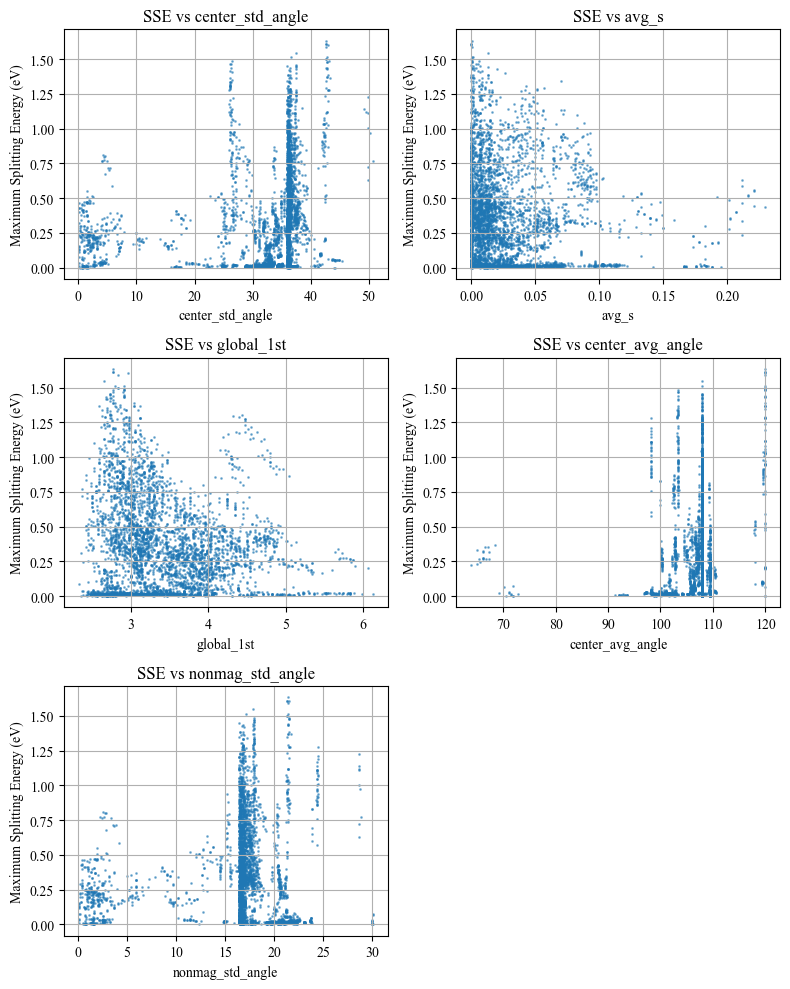

In [29]:
# Re-import the file after upload
#file_path = "/mnt/data/AL_ML_data.csv"
import matplotlib.pyplot as plt
df = merge_df

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'cm'
# Define target and top 5 features
target = 'maximum splitting energy'
top_5_features = ['center_std_angle', 'avg_s', 'global_1st', 'center_avg_angle', 'nonmag_std_angle']

# Plot scatter plots of each top feature against SSE
plt.figure(figsize=(8, 10))
for i, feature in enumerate(top_5_features, 1):
    plt.subplot(3, 2, i)
    plt.scatter(df[feature], df[target], alpha=0.5, s= 1)
    plt.xlabel(feature)
    plt.ylabel("Maximum Splitting Energy (eV)")
    plt.title(f"SSE vs {feature}")
    plt.grid(True)

plt.tight_layout()
plt.show()
